In [1]:
import os
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import zscore

from tabletop_py.gaze.preprocess import (
    clean_marker_data,
    format_marker_columns,
    verify_timestamps,
)

In [2]:
session_name = "session_2026-01-28_23-44-36"
marker_idx = 0

In [3]:
config = os.path.join(
    os.environ["TABLETOP_DIR"], "config", "gaze_estimation.yaml"
)
with open(config, "r") as f:
    config = cast(dict[str, Any], yaml.safe_load(f))

markers_freq = config["markers_freq"]
config = cast(dict[str, Any], config["preprocess"])

session_dir = os.path.join(os.environ["ROS_BAG_DIR"], session_name)

markers_path = os.path.join(session_dir, "markers.csv")
teensy_path = os.path.join(session_dir, "teensy_sensor.csv")

raw_markers_df = pd.read_csv(markers_path, index_col=False)
raw_teensy_df = pd.read_csv(teensy_path, index_col=False)

In [4]:
markers_df = format_marker_columns(
    raw_markers_df,
    marker_idx=marker_idx,
    freq=markers_freq,
    **config["format_marker"],
)

markers_df = clean_marker_data(markers_df, **config["clean_marker"])
markers_df

,time,marker_x,marker_y,marker_z
0,1.769644e+09,-0.029031,0.005516,0.471725
1,1.769644e+09,-0.029038,0.005520,0.471724
2,1.769644e+09,-0.029037,0.005517,0.471722
3,1.769644e+09,-0.029029,0.005516,0.471721
4,1.769644e+09,-0.029027,0.005512,0.471721
...,...,...,...,...
6034,1.769644e+09,-0.029055,0.005507,0.471686
6035,1.769644e+09,-0.029051,0.005501,0.471688
6036,1.769644e+09,-0.029049,0.005504,0.471693
6037,1.769644e+09,-0.029049,0.005500,0.471691


In [5]:
# TEENSY_DATA_COLS = [
#     "is_safety_laser_broken",
#     "is_left_arm_locked",
#     "is_right_arm_locked",
#     "is_reward_active",
#     "is_button_pressed",
#     "is_smartglass_revealed",
#     "left_tactile_glove_states",
#     "right_tactile_glove_states",
#     "sync_pulse_state",
#     "sync_pulse_last_time_on",
#     "sync_pulse_last_time_off",
#     "safety_laser_last_time_broken",
#     "button_last_time_pressed",
# ]
TEENSY_DATA_COLS = [
    "sync_pulse_state",
    "sync_pulse_last_time_on",
    "sync_pulse_last_time_off",
]


def format_teensy_columns(
    df: pd.DataFrame,
    *,
    freq: float,
    verify: bool = True,
    freq_rtol: float | None = None,
    freq_var_tol: float | None = None,
) -> pd.DataFrame:
    """
    Formats the timestamps to seconds and checks for monotonicity.

    Args:
        df: The teensy sensor data.
        freq: The expected frequency of the data.
        verify: Whether to verify the timestamps and monotonicity.
        freq_rtol: The relative tolerance for the frequency.
        freq_var_tol: The absolute tolerance for the frequency.

    Returns:
        The formatted eye tracker data.
    """
    df = df.copy()

    # Convert ROS timestamp to seconds
    df["time"] = df["header.stamp.sec"] + df["header.stamp.nanosec"] / 1e9
    df["sync_pulse_last_time_on"] = (
        df["sync_pulse_last_time_on.sec"]
        + df["sync_pulse_last_time_on.nanosec"] / 1e9
    )
    df["sync_pulse_last_time_off"] = (
        df["sync_pulse_last_time_off.sec"]
        + df["sync_pulse_last_time_off.nanosec"] / 1e9
    )
    df["safety_laser_last_time_broken"] = (
        df["safety_laser_last_time_broken.sec"]
        + df["safety_laser_last_time_broken.nanosec"] / 1e9
    )
    df["button_last_time_pressed"] = (
        df["button_last_time_pressed.sec"]
        + df["button_last_time_pressed.nanosec"] / 1e9
    )

    if verify:
        if freq_rtol is None or freq_var_tol is None:
            raise ValueError(
                "freq_rtol and freq_var_tol must be provided if verify is True"
            )

        # Convert timestamps to seconds
        df["bag_time"] = df.bag_time_ns / 1e9

        # Verify the timestamps
        verify_timestamps(
            df[["time", "bag_time"]],  # type: ignore
            freq,
            freq_rtol=freq_rtol,
            freq_var_tol=freq_var_tol,
        )

    df = cast(
        pd.DataFrame,
        df[["time", *TEENSY_DATA_COLS]],
    )

    return df


teensy_df = format_teensy_columns(raw_teensy_df, freq=100, verify=False)
teensy_df

,time,sync_pulse_state,sync_pulse_last_time_on,sync_pulse_last_time_off
0,1.769644e+09,False,1.769644e+09,1.769644e+09
1,1.769644e+09,False,1.769644e+09,1.769644e+09
2,1.769644e+09,False,1.769644e+09,1.769644e+09
3,1.769644e+09,False,1.769644e+09,1.769644e+09
4,1.769644e+09,False,1.769644e+09,1.769644e+09
...,...,...,...,...
5114,1.769644e+09,False,1.769644e+09,1.769644e+09
5115,1.769644e+09,False,1.769644e+09,1.769644e+09
5116,1.769644e+09,False,1.769644e+09,1.769644e+09
5117,1.769644e+09,False,1.769644e+09,1.769644e+09


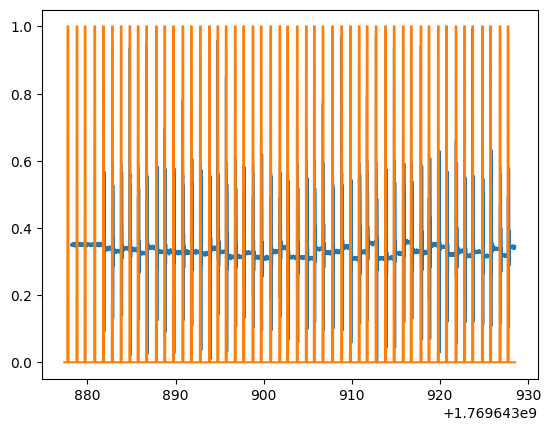

In [6]:
markers_y = (markers_df["marker_y"] - markers_df["marker_y"].min()) / (
    markers_df["marker_y"].max() - markers_df["marker_y"].min()
)
plt.plot(markers_df["time"], markers_y)
plt.plot(teensy_df["time"], teensy_df["sync_pulse_state"])

In [17]:
sync_on_idx = teensy_df["sync_pulse_last_time_on"].diff() > 1e-3
sync_on_times = teensy_df["sync_pulse_last_time_on"][sync_on_idx]
sync_off_idx = teensy_df["sync_pulse_last_time_off"].diff() > 1e-3
sync_off_times = teensy_df["sync_pulse_last_time_off"][sync_off_idx]
print(
    f"Sync pulse count | ON: {sync_on_times.count()}, OFF: {sync_off_times.count()}"
)
sync_times = np.sort(np.concat([sync_on_times, sync_off_times]))
sync_times.shape

Sync pulse count | ON: 51, OFF: 51


(102,)

In [16]:
markers_df["speed"] = np.linalg.norm(
    np.gradient(
        markers_df[["marker_x", "marker_y", "marker_z"]],
        markers_df["time"],
        axis=0,
    ),
    axis=1,
)
markers_df["speed_zscore"] = zscore(markers_df["speed"])
marker_moving = markers_df[markers_df["speed_zscore"] > 0.3]
time_diff = marker_moving["time"].diff()
marker_onsets = marker_moving[time_diff.isna() | (time_diff > 0.03)]
marker_times = np.sort(marker_onsets["time"].to_numpy())
marker_times.shape

(94,)

In [18]:
min_time = min(sync_times.min(), marker_times.min())
max_time = max(sync_times.max(), marker_times.max())
sync_times = sync_times - min_time
marker_times = marker_times - min_time

In [19]:
sync_times

array([ 0.        ,  0.10001206,  1.04599786,  1.14600992,  1.95718956,
        2.05721331,  3.05101228,  3.15117836,  4.04500747,  4.14506292,
        5.05201077,  5.15202284,  6.05500507,  6.15501833,  7.04402995,
        7.14404202,  7.98127031,  8.08128238,  8.94223714,  9.04224801,
       10.05004072, 10.15005279, 10.99604177, 11.09605312, 11.98904109,
       12.08907175, 13.05009079, 13.15006208, 14.02512264, 14.12506914,
       15.04200912, 15.14210367, 16.08500886, 16.18504977, 17.01805377,
       17.11806583, 17.97005033, 18.07008052, 19.00309205, 19.10310388,
       19.94807291, 20.04808497, 21.01514125, 21.11510015, 21.94809985,
       22.04811192, 23.02409697, 23.12410879, 24.05729222, 24.15728736,
       24.94111753, 25.04109836, 26.04110527, 26.14111733, 27.07107544,
       27.1710875 , 27.97807384, 28.07812309, 28.96214151, 29.06215358,
       30.04115629, 30.14119649, 31.08513451, 31.18513489, 32.07914257,
       32.17915297, 33.0721395 , 33.17215157, 33.97012901, 34.07

In [20]:
marker_times

array([ 4.05823851,  4.18325305,  5.06649399,  5.19154596,  6.07479334,
        6.19981217,  7.05808949,  7.18308663,  7.99970174,  8.12467813,
        8.95803428,  9.07470274, 10.06628609, 10.20778775, 11.01609755,
       11.13288903, 12.00768375, 12.12436175, 13.06600237, 13.20760703,
       14.04087186, 14.16596293, 15.05751276, 15.19090748, 16.09921026,
       16.24087811, 17.03245831, 17.17416978, 17.98233938, 18.12402534,
       19.01574135, 19.14906836, 19.96570945, 20.0905385 , 21.03226233,
       21.14887428, 21.96545267, 22.08214045, 23.0405066 , 23.17495775,
       24.07405758, 24.21542239, 24.95705342, 25.09051013, 26.05705047,
       26.18201661, 27.09423518, 27.24422193, 27.99012446, 28.11518502,
       28.98178983, 29.09851718, 30.05673575, 30.1901443 , 31.09836888,
       31.22334456, 32.09824395, 32.2233417 , 33.08986378, 33.2233088 ,
       33.98978114, 34.10640764, 35.00645018, 35.1480968 , 36.07312083,
       36.22319245, 37.05635405, 37.18967414, 38.08960319, 38.23

In [21]:
diffs_easy = marker_times - sync_times[8:]
diffs_easy

array([0.01323104, 0.03819013, 0.01448321, 0.03952312, 0.01978827,
       0.04479384, 0.01405954, 0.03904462, 0.01843143, 0.04339576,
       0.01579714, 0.03245473, 0.01624537, 0.05773497, 0.02005577,
       0.03683591, 0.01864266, 0.03529   , 0.01591158, 0.05754495,
       0.01574922, 0.04089379, 0.01550364, 0.04880381, 0.0142014 ,
       0.05582833, 0.01440454, 0.05610394, 0.01228905, 0.05394483,
       0.0126493 , 0.04596448, 0.01763654, 0.04245353, 0.01712108,
       0.03377414, 0.01735282, 0.03402853, 0.01640964, 0.05084896,
       0.01676536, 0.05813503, 0.0159359 , 0.04941177, 0.0159452 ,
       0.04089928, 0.02315974, 0.07313442, 0.01205063, 0.03706193,
       0.01964831, 0.0363636 , 0.01557946, 0.04894781, 0.01323438,
       0.03820968, 0.01910138, 0.04418874, 0.01772428, 0.05115724,
       0.01965213, 0.03622937, 0.01425743, 0.05596447, 0.0149436 ,
       0.06500411, 0.01217341, 0.04555988, 0.01748419, 0.05943489,
       0.01371741, 0.06372261, 0.01489663, 0.06465578, 0.01595

In [13]:
print(f"Latency: {diffs_easy.mean():.4f}s +- {diffs_easy.std():.4f}s")

Latency: 0.0323s +- 0.0182s


In [14]:
sync_idx = len(sync_times) - 1
marker_idx = len(marker_times) - 1
last_diff = None
diffs = []

while sync_idx >= 0 and marker_idx >= 0:
    sync_time = sync_times[sync_idx]
    marker_time = marker_times[marker_idx]

    diff = marker_time - sync_time
    if diff < 0:
        if last_diff is not None:
            diffs.append(last_diff)
            last_diff = None
        sync_idx -= 1
    else:
        if last_diff is None or diff < last_diff:
            last_diff = diff
        marker_idx -= 1

diffs = np.array(list(reversed(diffs)))
diffs

array([0.03819013, 0.01448321, 0.03952312, 0.01978827, 0.04479384,
       0.01405954, 0.03904462, 0.01843143, 0.04339576, 0.01579714,
       0.03245473, 0.01624537, 0.05773497, 0.02005577, 0.03683591,
       0.01864266, 0.03529   , 0.01591158, 0.05754495, 0.01574922,
       0.04089379, 0.01550364, 0.04880381, 0.0142014 , 0.05582833,
       0.01440454, 0.05610394, 0.01228905, 0.05394483, 0.0126493 ,
       0.04596448, 0.01763654, 0.04245353, 0.01712108, 0.03377414,
       0.01735282, 0.03402853, 0.01640964, 0.05084896, 0.01676536,
       0.05813503, 0.0159359 , 0.04941177, 0.0159452 , 0.04089928,
       0.02315974, 0.07313442, 0.01205063, 0.03706193, 0.01964831,
       0.0363636 , 0.01557946, 0.04894781, 0.01323438, 0.03820968,
       0.01910138, 0.04418874, 0.01772428, 0.05115724, 0.01965213,
       0.03622937, 0.01425743, 0.05596447, 0.0149436 , 0.06500411,
       0.01217341, 0.04555988, 0.01748419, 0.05943489, 0.01371741,
       0.06372261, 0.01489663, 0.06465578, 0.01595449, 0.07421

In [15]:
print(f"Latency: {diffs_easy.mean():.4f}s +- {diffs_easy.std():.4f}s")

Latency: 0.0323s +- 0.0182s
